# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [3]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

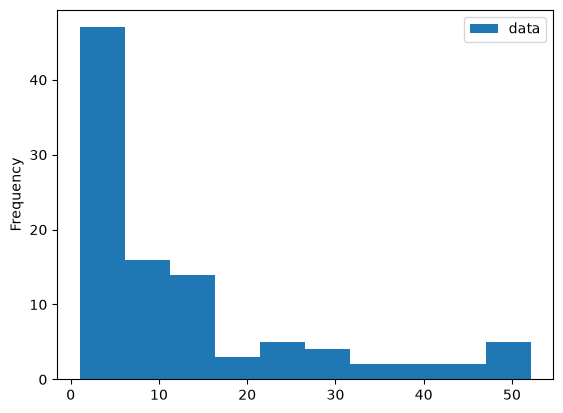

In [5]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

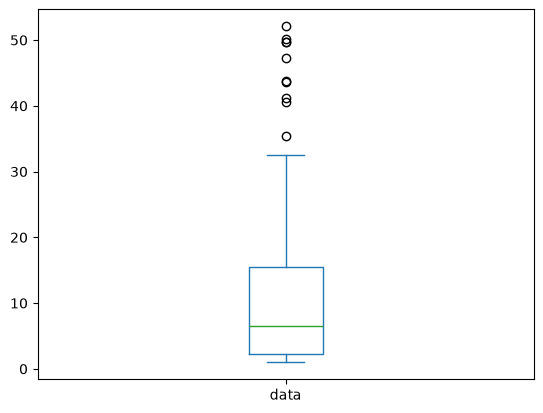

In [6]:
df.plot.box()

**Histogram - pros and cons.**
The histogram shows the *full shape* of the price distribution: you can see that most drugs are cheap and that there's a long right tail of expensive ones (this is an exponential/log-style distribution). Its weakness for this particular question is that the expensive drugs - the thing the administrator actually cares about - land in sparse bins way out on the right that are easy to overlook. It also doesn't put a clean number on "where does expensive begin."

**Boxplot - pros and cons.**
The boxplot is built for exactly this question. It marks the 75th percentile (the top of the box) as a clear threshold for "the pricier quarter of drugs," and it explicitly plots outliers as individual points beyond the upper whisker - so the genuinely expensive drugs are called out by name rather than buried. Its weakness is that it hides the shape: you can't tell whether prices are smoothly spread or clustered, and a non-technical administrator may not know how to read the box and whiskers.

**Which I'd choose.** For *this* administrator's question - "how much do the more expensive drugs tend to cost, relative to the rest" - the **boxplot** is the better fit, because the 75th-percentile line and the explicit outlier points directly answer it. If the audience were unfamiliar with boxplots, I'd show the histogram alongside it for intuition.

**Formatting changes I'd make:**
- Add axis labels and a title ("Drug prices, $") - the defaults have none.
- The data is heavily right-skewed, so I'd consider a **log-scaled x-axis** so the cheap drugs don't get crushed into one bar.
- On the boxplot, annotate the median and 75th-percentile values directly, and label or color the outlier points so the expensive drugs stand out.
- Use a calm single accent color and drop the default gridlines/chartjunk.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

## Setup and load
Dataset: Movies Box Office 2000-2024 (Kaggle). Same dataset as previous weeks.

In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

box = pd.read_csv('enhanced_box_office_data(2000-2024)u.csv')

# Convert 'Rating' from string '8.2/10' -> numeric, as in earlier weeks
box['Rating_num'] = box['Rating'].str.split('/').str[0].astype(float)
box.head()

,Rank,Release Group,$Worldwide,$Domestic,Domestic %,$Foreign,Foreign %,Year,Genres,Rating,Vote_Count,Original_Language,Production_Countries,Rating_num
0,1,Mission: Impossible II,546388108.0,215409889.0,39.4,330978219.0,60.6,2000,"Adventure, Action, Thriller",6.126/10,6741.0,en,United States of America,6.126
1,2,Gladiator,460583960.0,187705427.0,40.8,272878533.0,59.2,2000,"Action, Drama, Adventure",8.217/10,19032.0,en,"United Kingdom, United States of America",8.217
2,3,Cast Away,429632142.0,233632142.0,54.4,196000000.0,45.6,2000,"Adventure, Drama",7.663/10,11403.0,en,United States of America,7.663
3,4,What Women Want,374111707.0,182811707.0,48.9,191300000.0,51.1,2000,"Comedy, Romance",6.45/10,3944.0,en,"United Kingdom, United States of America",6.450
4,5,Dinosaur,349822765.0,137748063.0,39.4,212074702.0,60.6,2000,"Animation, Family, Adventure",6.544/10,2530.0,en,United States of America,6.544


## Means, medians, and modes

In [10]:
num_cols = ['$Worldwide','$Domestic','Domestic %','$Foreign','Foreign %',
            'Vote_Count','Rating_num']
stats = pd.DataFrame({
    'mean':   box[num_cols].mean(),
    'median': box[num_cols].median(),
})
stats

,mean,median
$Worldwide,1.192137e+08,48446575.00
$Domestic,4.472523e+07,17984212.00
Domestic %,3.574062e+01,37.05
$Foreign,7.448809e+07,30194438.00
Foreign %,6.425664e+01,62.95
Vote_Count,2.531586e+03,1035.50
Rating_num,6.510418e+00,6.60


In [11]:
# Mode is most meaningful for the categoricals
for c in ['Genres','Original_Language','Rating_num']:
    print(f'{c:>18} mode: {box[c].mode()[0]}')

            Genres mode: Comedy
 Original_Language mode: en
        Rating_num mode: 6.5


For the money columns the **mean is far above the median** (e.g. worldwide gross averages ~\$119M but the median is only ~\$48M). That gap is the classic signature of a **right-skewed** distribution - a few mega-blockbusters pull the average up. `Rating_num`, by contrast, has mean and median very close (~6.5), suggesting a roughly symmetric distribution.

## Histograms + variants for the numeric features
Following last week's toolkit: `histplot`, `kdeplot`, `boxplot`, `violinplot`.

### Worldwide gross - histogram (raw vs. log scale)

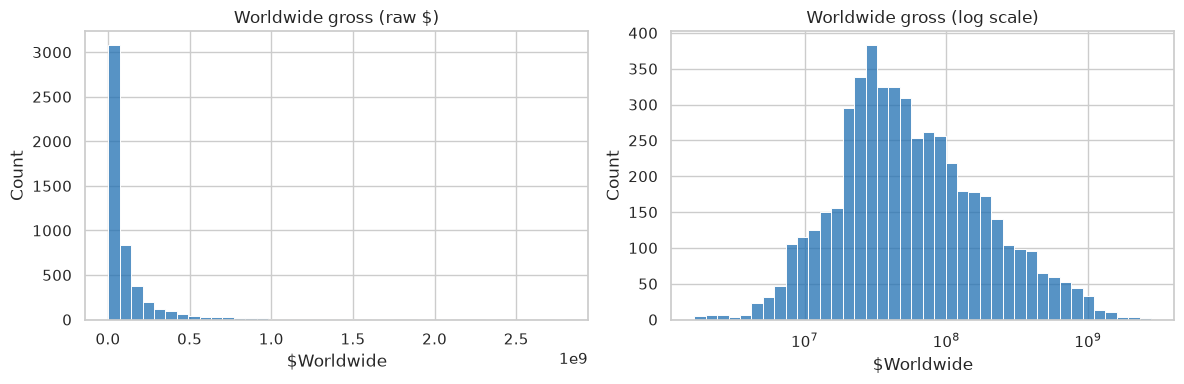

Min: $ 1666028
Max: $ 2799439100


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(box['$Worldwide'], bins=40, ax=axes[0], color='#1f6fb2')
axes[0].set_title('Worldwide gross (raw $)')

# Same data on a log scale to tame the skew
sns.histplot(box['$Worldwide'], bins=40, ax=axes[1], color='#1f6fb2', log_scale=True)
axes[1].set_title('Worldwide gross (log scale)')
plt.tight_layout(); plt.show()

print('Min: $', round(box['$Worldwide'].min()))
print('Max: $', round(box['$Worldwide'].max()))

**Bin size / scale matters a lot here.** On the raw axis almost every film piles into the first one or two bins and the blockbusters are invisible in a long flat tail - the histogram looks nearly empty. Putting the x-axis on a **log scale** reveals the real shape: a smooth, roughly bell-shaped curve *in log space*, which is the definition of a **log-normal** distribution. Min is ~\$1.7M, max is ~\$2.8B (Avatar-scale).

### KDE and boxplot for worldwide gross

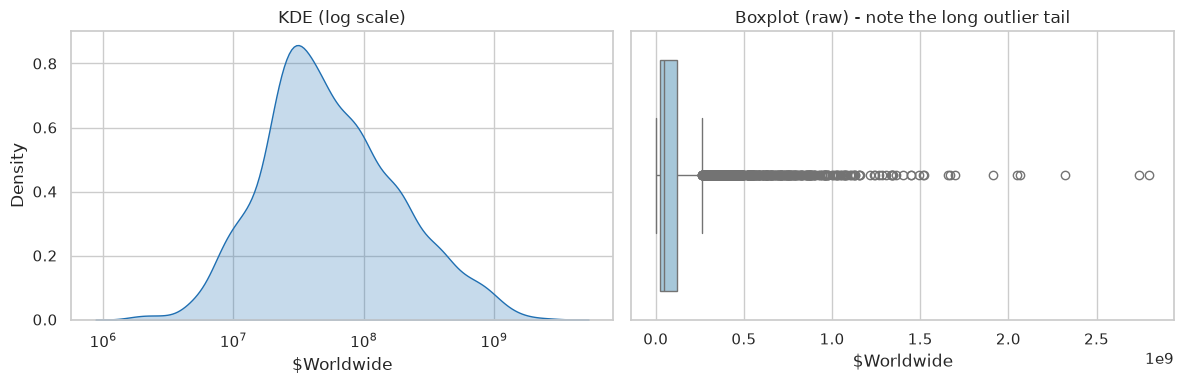

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(box['$Worldwide'], ax=axes[0], color='#1f6fb2', fill=True, log_scale=True)
axes[0].set_title('KDE (log scale)')
sns.boxplot(x=box['$Worldwide'], ax=axes[1], color='#9ecae1')
axes[1].set_title('Boxplot (raw) - note the long outlier tail')
plt.tight_layout(); plt.show()

The boxplot makes the **outliers** explicit: a dense cluster of points stretches far to the right of the upper whisker. These are the blockbusters - completely real data, not errors, but they dominate the upper tail.

### Vote_Count - another right-skewed feature

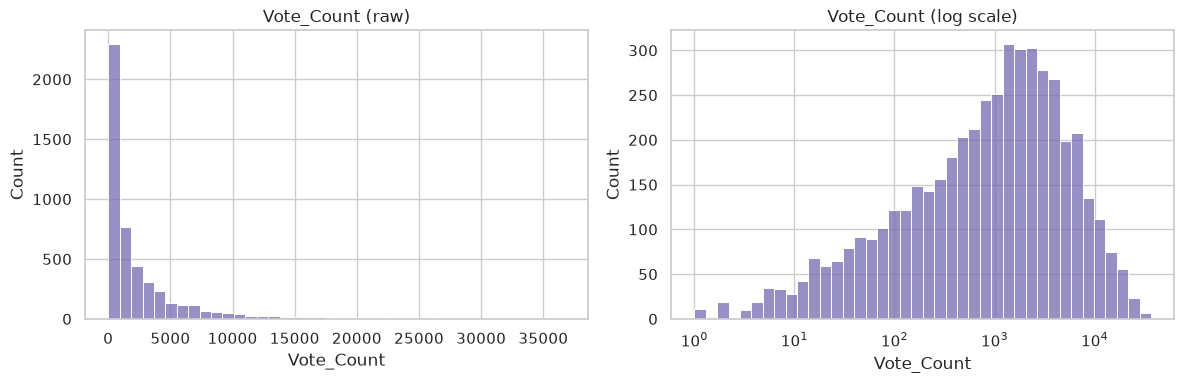

Min: 0.0  Max: 36753.0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(box['Vote_Count'].dropna(), bins=40, ax=axes[0], color='#756bb1')
axes[0].set_title('Vote_Count (raw)')
sns.histplot(box['Vote_Count'].dropna(), bins=40, ax=axes[1], color='#756bb1', log_scale=True)
axes[1].set_title('Vote_Count (log scale)')
plt.tight_layout(); plt.show()
print('Min:', box['Vote_Count'].min(), ' Max:', box['Vote_Count'].max())

Same story as gross: strongly right-skewed on a raw axis, roughly log-normal once log-scaled. Popularity (votes) and revenue behave alike.

### Rating - a (roughly) normal feature

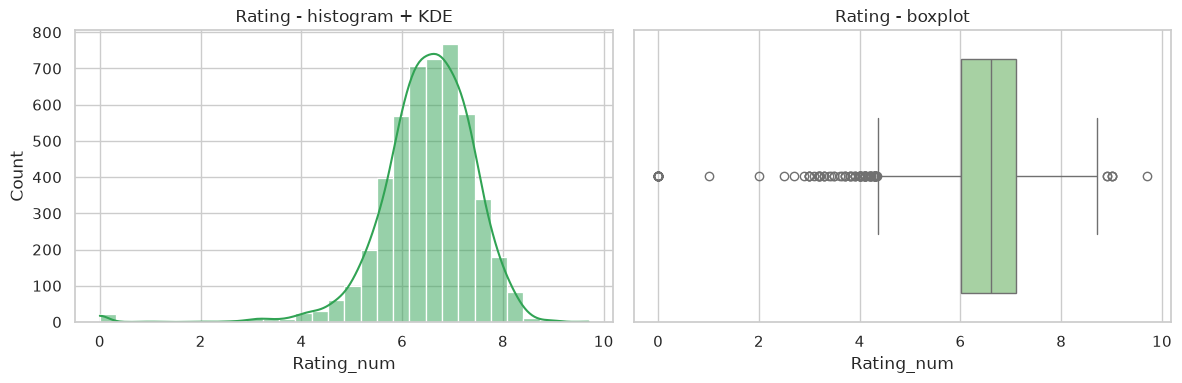

Min: 0.0  Max: 9.7


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(box['Rating_num'], bins=30, kde=True, ax=axes[0], color='#31a354')
axes[0].set_title('Rating - histogram + KDE')
sns.boxplot(x=box['Rating_num'], ax=axes[1], color='#a1d99b')
axes[1].set_title('Rating - boxplot')
plt.tight_layout(); plt.show()
print('Min:', box['Rating_num'].min(), ' Max:', box['Rating_num'].max())

`Rating_num` is the most **symmetric / near-normal** feature - a single hump centred around 6.5. The one wrinkle is a small spike at **0.0**, which are almost certainly unrated films coded as zero rather than truly terrible movies; they appear as low outliers in the boxplot.

### How bin width changes the picture (Rating)

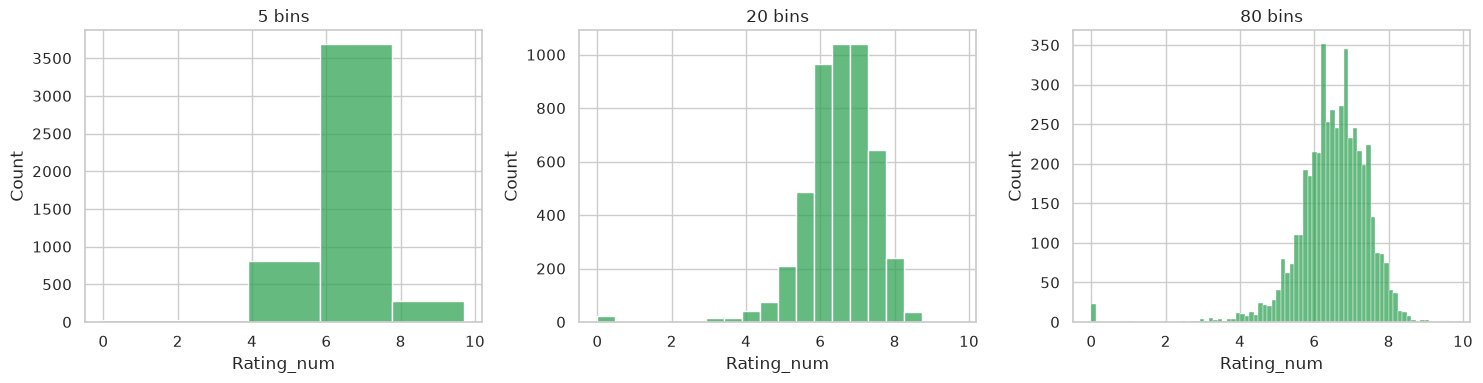

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, b in zip(axes, [5, 20, 80]):
    sns.histplot(box['Rating_num'], bins=b, ax=ax, color='#31a354')
    ax.set_title(f'{b} bins')
plt.tight_layout(); plt.show()

**Bin width experiment:** with only 5 bins the distribution looks like a smooth blob and the `0.0` spike is hidden. With 80 bins the curve gets noisy/"wobbly" (the small-sample-per-bin effect from last week) but the zero-rating spike and a slight clustering at round numbers become visible. ~20 bins is the sweet spot: enough detail to see the shape, not so many that chance noise takes over.

## Grouped histograms - distribution across categories
Comparing worldwide gross for the top languages (the "maple vs oak trees" idea).

/tmp/ipykernel_9499/3311548608.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=subset, x='Original_Language', y='$Worldwide',


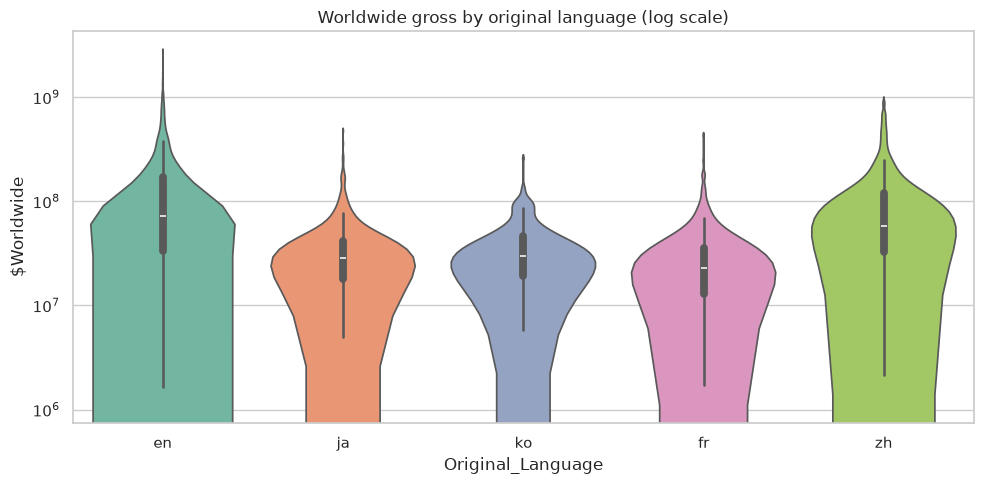

In [17]:
top_langs = ['en','ja','ko','fr','zh']
subset = box[box['Original_Language'].isin(top_langs)]

plt.figure(figsize=(10, 5))
sns.violinplot(data=subset, x='Original_Language', y='$Worldwide',
               order=top_langs, palette='Set2')
plt.yscale('log')
plt.title('Worldwide gross by original language (log scale)')
plt.tight_layout(); plt.show()

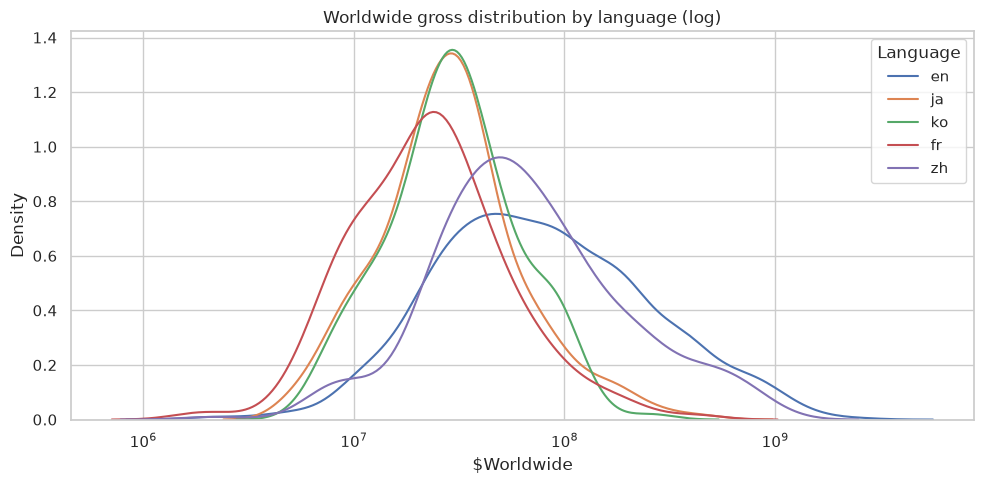

In [18]:
# KDE overlay version of the same comparison
plt.figure(figsize=(10, 5))
for lang in top_langs:
    sns.kdeplot(box.loc[box['Original_Language']==lang, '$Worldwide'],
                log_scale=True, label=lang, fill=False)
plt.legend(title='Language'); plt.title('Worldwide gross distribution by language (log)')
plt.tight_layout(); plt.show()

**How the distribution changes across groups:** English-language films sit noticeably higher and wider - their distribution is shifted toward larger grosses, reflecting Hollywood's global reach. Japanese, Korean, French and Chinese films cluster at lower grosses with tighter spreads. The *shape* (log-normal) is similar across all groups; what differs is the **location** (English shifted right).

## Bar plot - counts of a categorical column

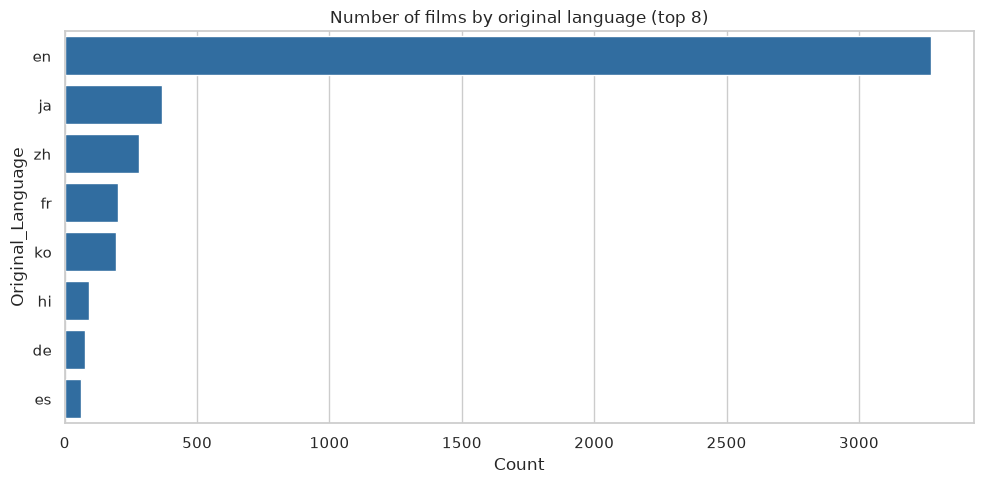

Original_Language
en    3271
ja     369
zh     280
fr     203
ko     194
hi      92
de      77
es      63
Name: count, dtype: int64


In [19]:
plt.figure(figsize=(10, 5))
order = box['Original_Language'].value_counts().head(8).index
sns.countplot(data=box, y='Original_Language', order=order, color='#1f6fb2')
plt.title('Number of films by original language (top 8)')
plt.xlabel('Count'); plt.tight_layout(); plt.show()

print(box['Original_Language'].value_counts().head(8))

The bar plot makes the **class imbalance** unmistakable: English (~3,300 films) dwarfs every other language. This matters for any modeling - "the typical movie" in this dataset is really "the typical English-language movie."

## Conclusions

**Are the data what I expect? Usable?** Yes. The distributions match domain intuition - a few blockbusters dominating revenue, ratings clustering around average - and nothing looks corrupted. The data are usable; the main cleaning need is treating `Rating_num == 0` as missing.

**Overall shape of the distributions:**
- `$Worldwide`, `$Domestic`, `$Foreign`, `Vote_Count` → strongly **right-skewed**, effectively **log-normal** (bell-shaped once log-transformed).
- `Rating_num` → roughly **normal / symmetric**, centred ~6.5, with a small artificial spike at 0.
- `Domestic %` / `Foreign %` → spread across the 0-100 range (more uniform-ish), since they're complementary shares.

**Outliers:** Present and expected in the money and vote columns - the blockbusters (up to ~\$2.8B). These are legitimate, not errors. The only suspicious points are the `0.0` ratings.

**Across groups:** Distribution shape is consistent across languages, but English films are shifted toward higher grosses.

**Min/max highlights:** Worldwide gross \$1.7M-\$2.8B; Vote_Count ranges into the tens of thousands; Rating 0-9.7.

**Bin size:** Crucial. Too few bins hides features (the 0-rating spike); too many introduces chance noise. For skewed money data, switching to a **log scale** does more than any bin choice to reveal the true shape.

**Normality:** Only `Rating_num` is close to normal. The financial features are decidedly **not** normal (log-normal), which is worth remembering before applying any method that assumes normality - a log transform would be the right preprocessing step.

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

I'm reproducing the **horizontal bar chart** style from the second half of Chapter 2 - Knaflic favors horizontal bars for categorical comparisons because the labels are easy to read, and she greys out everything except the one bar she wants the audience to focus on (the "preattentive attributes / direct attention with color" idea). I applied that to my own data: number of films by language, with English highlighted.

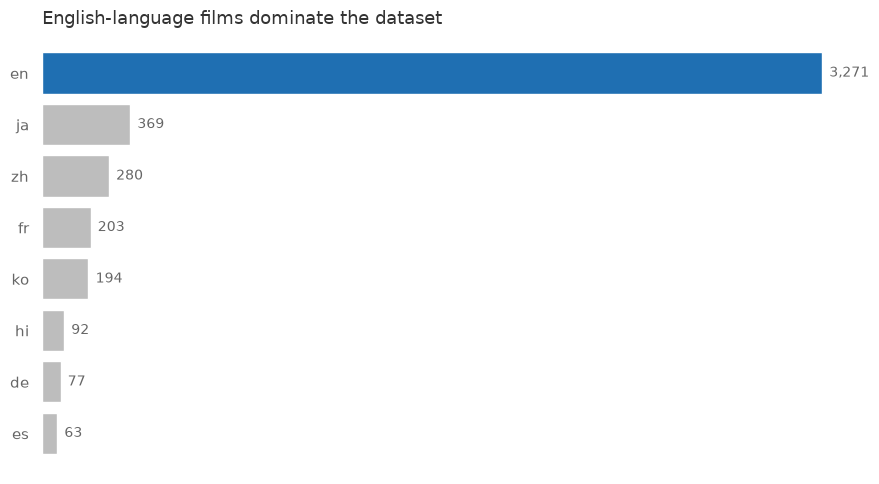

In [20]:
counts = box['Original_Language'].value_counts().head(8)[::-1]  # smallest at bottom
colors = ['#bdbdbd'] * len(counts)
colors[list(counts.index).index('en')] = '#1f6fb2'   # highlight English only

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(counts.index, counts.values, color=colors)

# Knaflic-style decluttering
for s in ['top', 'right', 'left']:
    ax.spines[s].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(left=False, bottom=False, labelbottom=False, colors='#666666')
ax.grid(False)

# Label values directly on the bars instead of using an axis
for y, v in enumerate(counts.values):
    ax.text(v + 30, y, f'{v:,}', va='center', color='#666666', fontsize=10)

ax.set_title('English-language films dominate the dataset',
             loc='left', fontsize=13, color='#333333')
plt.tight_layout(); plt.show()

**What I did / searched:** I looked up `matplotlib barh`, how to remove all spines/ticks for the clean Knaflic look, and `ax.text` to label values at the end of each bar instead of relying on a gridded axis. The key Storytelling-With-Data moves I copied: horizontal bars sorted by size, a single accent color on the bar that carries the message while the rest stay grey, value labels directly on the bars, and a sentence-style title that states the takeaway rather than just naming the axes.